# Link Prediction mit GINE

Gleiche Daten, gleicher Trainingsloop und gleicher Decoder wie in `GATV2.ipynb`, nur der
Message-Passing-Teil wird durch `GINEConv` ersetzt. Dadurch ist der Vergleich der beiden
Architekturen fair.

In [8]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gnn_pipeline import load_bundle, train_link_predictor, evaluate_link_predictor, plot_auc_history, plot_learning_curves

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

bundle = load_bundle(device=device)   # processed/philadelphia_split.pt
data, train_data, val_data, test_data = bundle.data, bundle.train, bundle.val, bundle.test

in_channels = data.x.size(1)
edge_dim = data.edge_attr.size(1)

Device: cuda
Split geladen: processed\philadelphia_split.pt
Knoten: 13389, Kanten: 40003
Knotenfeatures (2): ['x', 'y']
Kantenfeatures (17): ['Capacity', 'Length', 'free_flow_time', 'Toll', 'capacity_ratio', 'delta_x', 'delta_y', 'capacity_is_placeholder', 'has_reciprocal', 'link_type_1', 'link_type_2', 'link_type_3', 'link_type_4', 'link_type_6', 'link_type_7', 'link_type_8', 'link_type_9']
train: msg-passing Kanten=31995, Label-Paare pos=31995 neg=63990
val: msg-passing Kanten=31995, Label-Paare pos=3999 neg=7998
test: msg-passing Kanten=35994, Label-Paare pos=4009 neg=8018
val: positive Kanten mit Gegenrichtung im Train-Graph: 0/3999 (0.0%)
test: positive Kanten mit Gegenrichtung im Train-Graph: 0/4009 (0.0%)
meta: {'seed': 42, 'val_ratio': 0.1, 'test_ratio': 0.1, 'neg_sampling_ratio': 2.0, 'node_features': ['coords'], 'split': 'pair_aware', 'scale_edge_numerical': True}


## Graph Isomorphism Network mit Kantenfeatures (GINE)

GIN aggregiert Nachbarn per **Summe** und wendet dann ein MLP an – das ist so ausdrucksstark wie
der Weisfeiler-Lehman-Test. GINE (Hu et al., *Strategies for Pre-training GNNs*) erweitert dies um
Kantenfeatures:

$$x_i' = \mathrm{MLP}\Big((1+\epsilon)\, x_i + \sum_{j \in \mathcal{N}(i)} \mathrm{ReLU}(x_j + W_e\, e_{ji})\Big)$$

Über `edge_dim` projiziert `GINEConv` die Kantenfeatures linear auf die Knotendimension, damit
die Addition $x_j + W_e e_{ji}$ möglich ist.

**Unterschiede zu GATv2, die für die Interpretation wichtig sind:**
- keine Attention, alle Nachbarn zählen gleich (gewichtet nur durch die Kantenfeatures),
- Summen-Aggregation macht GINE sensibel für den Knotengrad – bei nur `x, y` als Knotenfeature
  ist das Eingangssignal dünn; `node_features=["coords", "node_type", "degree"]` in
  `data_prep.ipynb` ist ein naheliegendes Experiment,
- `BatchNorm` zwischen den Schichten stabilisiert die Summen.

In [9]:
import torch.nn as nn
from torch_geometric.nn import GINEConv

def _mlp(in_dim, out_dim):
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU(),
        nn.Linear(out_dim, out_dim),
    )

class GINELinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, dropout=0.3, train_eps=True):
        super().__init__()
        # Eingangsprojektion, damit die erste Schicht bereits in hidden_channels rechnet
        self.lin_in = nn.Linear(in_channels, hidden_channels)
        self.conv1 = GINEConv(_mlp(hidden_channels, hidden_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.conv2 = GINEConv(_mlp(hidden_channels, hidden_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.conv3 = GINEConv(_mlp(hidden_channels, out_channels), train_eps=train_eps, edge_dim=edge_dim)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.dropout = nn.Dropout(dropout)
        # identischer Decoder wie beim GATv2-Modell
        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1),
        )

    def forward(self, x, edge_index, edge_attr):
        x = self.lin_in(x).relu()
        x = self.dropout(self.bn1(self.conv1(x, edge_index, edge_attr)).relu())
        x = self.dropout(self.bn2(self.conv2(x, edge_index, edge_attr)).relu())
        return self.conv3(x, edge_index, edge_attr)

    def predict_link(self, node_embeddings, edge_label_index):
        src, dst = node_embeddings[edge_label_index[0]], node_embeddings[edge_label_index[1]]
        return self.decoder(torch.cat([src, dst], dim=1)).squeeze(-1)

In [10]:
MODEL_NAME = "GINE"
HIDDEN, OUT = 128, 256
EPOCHS, LR, WEIGHT_DECAY = 300, 0.005, 0.0

torch.manual_seed(bundle.meta.get("seed", 42))
model = GINELinkPredictor(in_channels, HIDDEN, OUT, edge_dim).to(device)
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters()):,}")

GINELinkPredictor(
  (lin_in): Linear(in_features=2, out_features=128, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  ))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, 

Epoch 001 | train loss 0.6839 | val AUC 0.7087 | test AUC 0.7095
Epoch 010 | train loss 0.6358 | val AUC 0.5481 | test AUC 0.5591
Epoch 020 | train loss 0.6105 | val AUC 0.3738 | test AUC 0.3730
Epoch 030 | train loss 0.5907 | val AUC 0.4474 | test AUC 0.4515
Epoch 040 | train loss 0.4521 | val AUC 0.7465 | test AUC 0.7500
Epoch 050 | train loss 0.3532 | val AUC 0.8474 | test AUC 0.8491
Epoch 060 | train loss 0.2717 | val AUC 0.8790 | test AUC 0.8797
Epoch 070 | train loss 0.3188 | val AUC 0.8934 | test AUC 0.9014
Epoch 080 | train loss 0.2170 | val AUC 0.9239 | test AUC 0.9299
Epoch 090 | train loss 0.1757 | val AUC 0.9375 | test AUC 0.9416
Epoch 100 | train loss 0.1518 | val AUC 0.9447 | test AUC 0.9515
Epoch 110 | train loss 0.1335 | val AUC 0.9577 | test AUC 0.9578
Epoch 120 | train loss 0.1282 | val AUC 0.9589 | test AUC 0.9585
Epoch 130 | train loss 0.1219 | val AUC 0.9591 | test AUC 0.9600
Epoch 140 | train loss 0.1133 | val AUC 0.9613 | test AUC 0.9641
Epoch 150 | train loss 0.

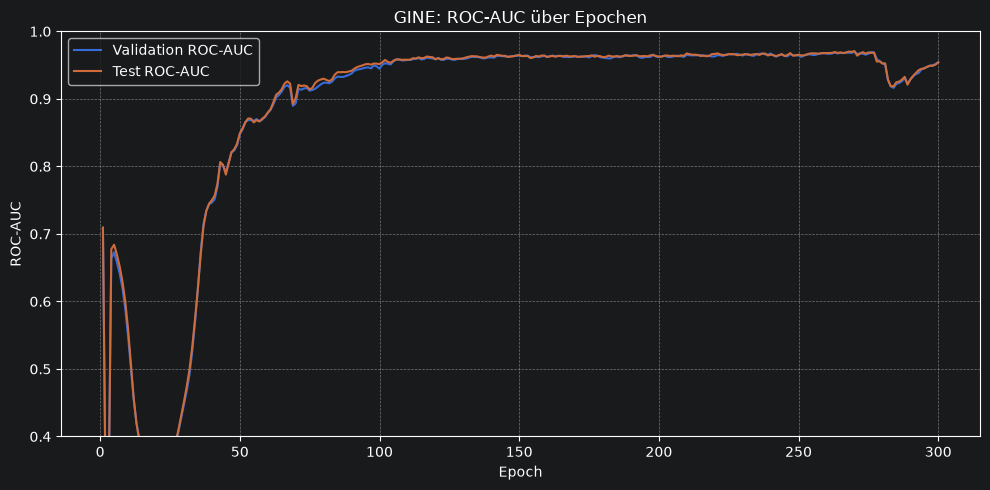

Finale Test-Loss 0.2669 | Test-ROC-AUC 0.9539


In [11]:
history = train_link_predictor(
    model, train_data, val_data, test_data,
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, log_every=10,
)
plot_auc_history(history, title=f'{MODEL_NAME}: ROC-AUC über Epochen')
plt.show()

test_loss, test_auc = evaluate_link_predictor(model, train_data, test_data)
print(f"Finale Test-Loss {test_loss:.4f} | Test-ROC-AUC {test_auc:.4f}")

## Learning Curve

`plot_learning_curves` (in `gnn_pipeline/training.py`) zeigt die komplette `history` aus dem Trainingsloop:
links den BCE-Loss für Train/Val/Test (log-Skala, gleiche Darstellung wie in `GATV2.ipynb`), rechts die ROC-AUC
für Val/Test. Die graue Linie markiert die Epoche mit der besten Val-AUC – dort wird auch der Test-Wert
abgelesen, den man für einen fairen Vergleich mit GATv2 verwenden würde (Modellauswahl auf Val, nicht auf Test).

**Was man im Lauf oben sieht:**
- GINE lernt sofort: AUC ≈ 0.9 bereits nach ~50 Epochen, kein langes Plateau wie bei GATv2.
- Ab ~Epoche 120 geht die Schere auf: Train-Loss sinkt weiter (bis ≈ 0.08), Val-/Test-Loss steigen wieder auf
  ≈ 0.4–0.5. Das ist klassisches Overfitting *im Loss* (die Logits werden zu selbstsicher) – die AUC bleibt
  trotzdem stabil bei ≈ 0.96–0.97, weil die Rangordnung der Kanten noch stimmt.
- Zwischen Epoche ~275 und ~290 springt auch der Train-Loss hoch und die AUC fällt auf ≈ 0.93: eine
  Optimierer-Instabilität (lr = 0.005 ohne Scheduler, Summen-Aggregation). Dadurch liegt die finale Test-AUC
  (0.954) deutlich unter dem Wert an der besten Val-Epoche (0.971) → ein Checkpoint auf der besten Val-AUC oder
  Early Stopping würde hier direkt ~1.7 Punkte bringen.

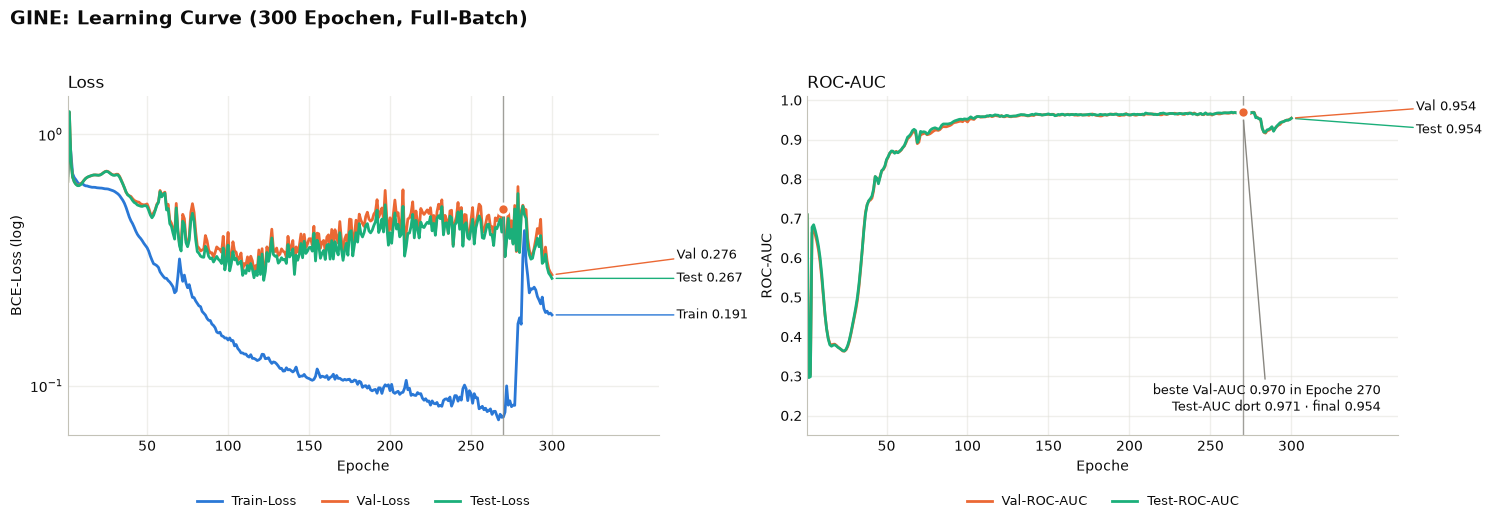

In [16]:
plot_learning_curves(history, title=f"{MODEL_NAME}: Learning Curve (300 Epochen, Full-Batch)")
plt.show()

In [12]:
## Ablation (temporär, von Claude eingefügt): Woran scheitert GINE?
# Jeder Lauf trainiert 300 Epochen mit demselben Loop wie gnn_pipeline, ohne `model` zu überschreiben.
import time
from torch_geometric.nn import GINEConv
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score

num_idx = list(range(7))  # Capacity..delta_y = numerische Kantenspalten
def standardize(ea, ref):
    ea = ea.clone()
    mu, sd = ref[:, num_idx].mean(0), ref[:, num_idx].std(0)
    ea[:, num_idx] = (ea[:, num_idx] - mu) / sd
    return ea
ea_raw = train_data.edge_attr
ea_scaled = standardize(ea_raw, data.edge_attr)
ea_zero = torch.zeros_like(ea_raw)

def make_gine(aggr="add", dropout=0.3):
    m = GINELinkPredictor(in_channels, 128, 256, edge_dim, dropout=dropout)
    if aggr != "add":
        for name in ("conv1", "conv2", "conv3"):
            old = getattr(m, name)
            setattr(m, name, GINEConv(old.nn, train_eps=True, edge_dim=edge_dim, aggr=aggr))
    return m

class CoordsOnly(nn.Module):
    """Kein Message Passing: nur MLP auf (x,y) + derselbe Decoder."""
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 256))
        self.decoder = nn.Sequential(nn.Linear(512, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, x, ei, ea): return self.enc(x)
    def predict_link(self, emb, eli): return self.decoder(torch.cat([emb[eli[0]], emb[eli[1]]], 1)).squeeze(-1)

def run(name, make_model, edge_attr, epochs=300, lr=0.005):
    torch.manual_seed(42)
    m = make_model().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    lf = BCEWithLogitsLoss()
    t0, best = time.time(), 0.0
    for ep in range(1, epochs + 1):
        m.train(); opt.zero_grad()
        emb = m(train_data.x, train_data.edge_index, edge_attr)
        loss = lf(m.predict_link(emb, train_data.edge_label_index), train_data.edge_label.float())
        loss.backward(); opt.step()
        if ep % 75 == 0 or ep == epochs:
            m.eval()
            with torch.no_grad():
                emb = m(train_data.x, train_data.edge_index, edge_attr)
                tr = roc_auc_score(train_data.edge_label.cpu(), m.predict_link(emb, train_data.edge_label_index).cpu())
                va = roc_auc_score(val_data.edge_label.cpu(), m.predict_link(emb, val_data.edge_label_index).cpu())
            best = max(best, va)
            print(f"{name:34s} ep {ep:3d} loss {loss.item():.4f} trainAUC {tr:.3f} valAUC {va:.3f}", flush=True)
    print(f"  => {name}: beste valAUC {best:.3f} ({time.time()-t0:.0f}s)", flush=True)
    print()

run("A GINE, Kanten roh (wie Notebook)", make_gine, ea_raw)
run("B GINE, Kanten skaliert",          make_gine, ea_scaled)
run("C GINE, Kanten = 0 (ohne)",        make_gine, ea_zero)
run("D GINE skaliert, aggr=mean",       lambda: make_gine("mean"), ea_scaled)
run("E GINE skaliert, dropout=0",       lambda: make_gine(dropout=0.0), ea_scaled)
run("F nur Koordinaten-MLP, kein GNN",  CoordsOnly, ea_zero)

A GINE, Kanten roh (wie Notebook)  ep  75 loss 0.1901 trainAUC 0.974 valAUC 0.928
A GINE, Kanten roh (wie Notebook)  ep 150 loss 0.1306 trainAUC 0.989 valAUC 0.963
A GINE, Kanten roh (wie Notebook)  ep 225 loss 0.0861 trainAUC 0.995 valAUC 0.973
A GINE, Kanten roh (wie Notebook)  ep 300 loss 0.0382 trainAUC 1.000 valAUC 0.988
  => A GINE, Kanten roh (wie Notebook): beste valAUC 0.988 (104s)

B GINE, Kanten skaliert            ep  75 loss 0.2323 trainAUC 0.963 valAUC 0.922
B GINE, Kanten skaliert            ep 150 loss 0.1032 trainAUC 0.993 valAUC 0.969
B GINE, Kanten skaliert            ep 225 loss 0.1033 trainAUC 0.993 valAUC 0.968
B GINE, Kanten skaliert            ep 300 loss 0.0862 trainAUC 0.995 valAUC 0.974
  => B GINE, Kanten skaliert: beste valAUC 0.974 (104s)

C GINE, Kanten = 0 (ohne)          ep  75 loss 0.2283 trainAUC 0.973 valAUC 0.937
C GINE, Kanten = 0 (ohne)          ep 150 loss 0.1051 trainAUC 0.994 valAUC 0.973
C GINE, Kanten = 0 (ohne)          ep 225 loss 0.0602 tr

## Visualisierung der Knoten-Embeddings

PCA der gelernten Embeddings auf 2 Dimensionen, eingefärbt nach Knotentyp (Zone / Kreuzung).

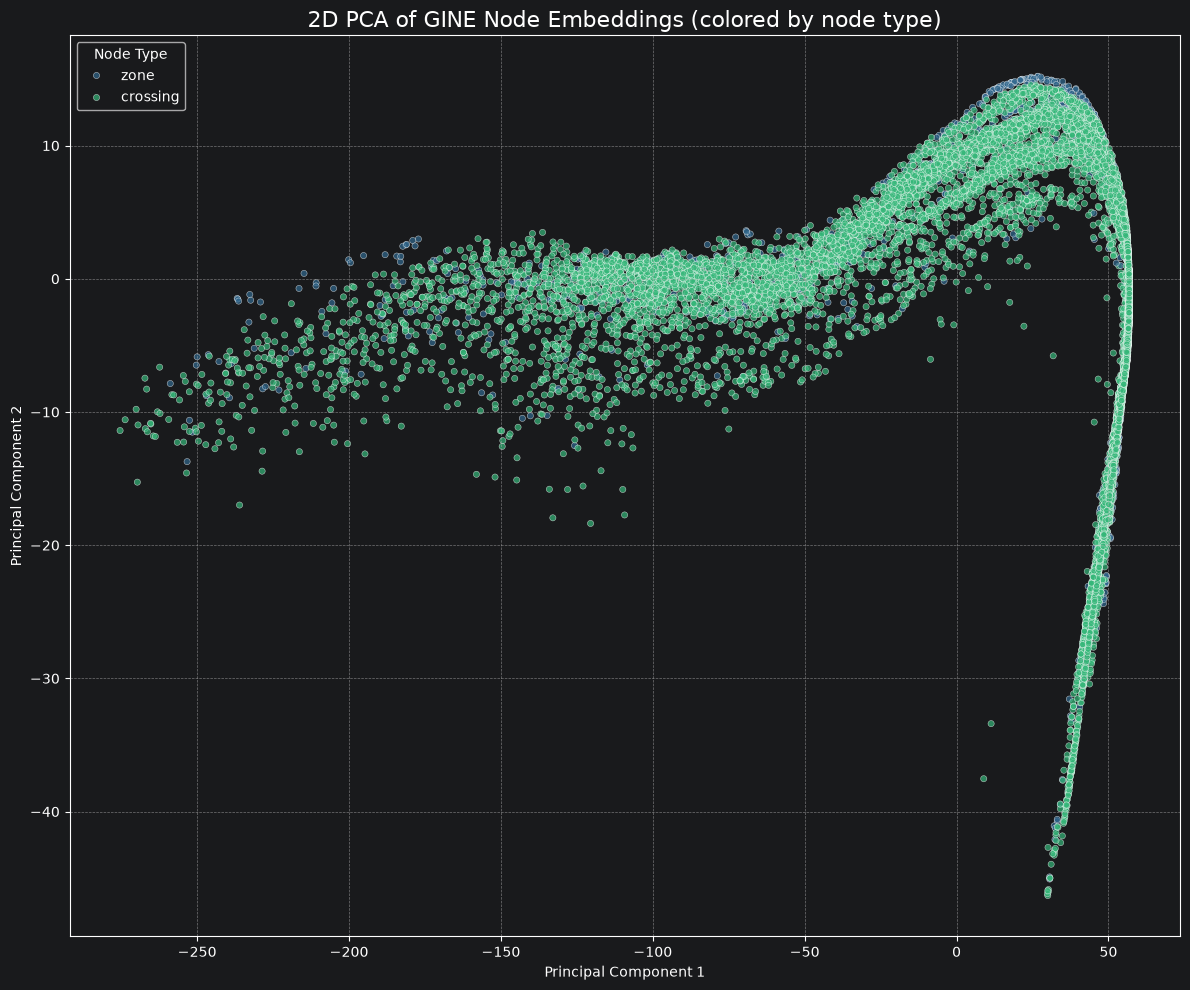

In [13]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    emb = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

emb_2d = PCA(n_components=2).fit_transform(emb)
plot_df = pd.DataFrame({'component_1': emb_2d[:, 0], 'component_2': emb_2d[:, 1], 'node_type': bundle.node_type})

plt.figure(figsize=(12, 10))
sns.scatterplot(data=plot_df, x='component_1', y='component_2', hue='node_type', palette='viridis', alpha=0.7, s=20)
plt.title(f'2D PCA of {MODEL_NAME} Node Embeddings (colored by node type)', size=16)
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.legend(title='Node Type'); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout()
plt.show()

## Feature-Analyse: Korrelation der Kantenfeatures mit dem Label

Pearson-Korrelation jedes Kantenfeatures (aus `edge_label_attr`) mit `edge_label` im Trainingssplit.
Hinweis: Negative Beispiele tragen zufällig gezogene Features, daher sind hohe Korrelationen hier nicht zu erwarten.

link_type_4                0.004442
link_type_8                0.002738
Toll                       0.001913
capacity_ratio             0.001679
capacity_is_placeholder    0.001161
Capacity                   0.001144
link_type_7                0.001118
link_type_9                0.000472
free_flow_time             0.000414
Length                     0.000354
link_type_1               -0.000196
delta_x                   -0.000224
delta_y                   -0.000635
link_type_6               -0.000763
link_type_2               -0.000951
has_reciprocal            -0.001990
link_type_3               -0.005634
Name: edge_label, dtype: float64


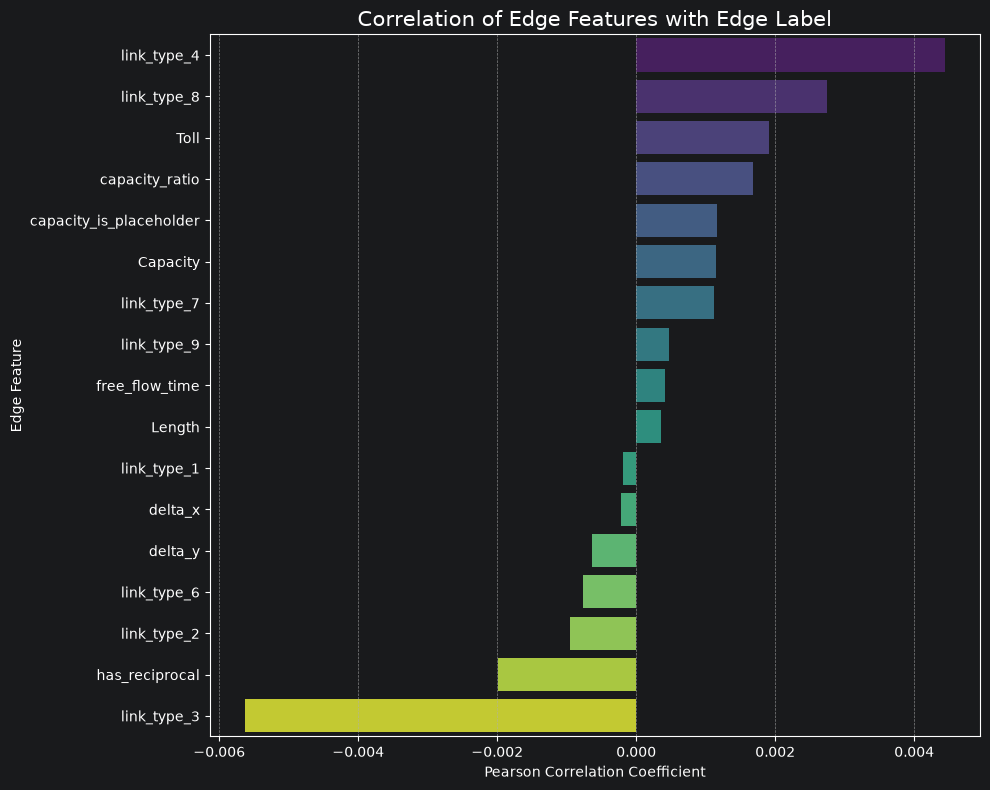

In [14]:
features_df = pd.DataFrame(train_data.edge_label_attr.cpu().numpy(), columns=bundle.edge_attr_columns)
features_df['edge_label'] = train_data.edge_label.cpu().numpy()
corr = features_df.corr()['edge_label'].drop('edge_label').sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette='viridis', legend=False)
plt.title('Correlation of Edge Features with Edge Label', size=15)
plt.xlabel('Pearson Correlation Coefficient'); plt.ylabel('Edge Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7); plt.tight_layout()
plt.show()